# Bias-Variance, Regularization & Ensemble Learning
## Interactive Proseminar Notebook — MI-ADM Lecture 4

This notebook accompanies the proseminar slides. It provides **live code demonstrations** for every method covered in the lecture.

### Structure
1. **Setup & Toy Data**
2. **Bias-Variance Visualization**
3. **KNN Bias-Variance**
4. **Regularization Demo** (Ridge & Lasso)
5. **Bagging Demo**
6. **Boosting Demo**
7. **Random Forests** (if sklearn available)
8. **Bagging vs Boosting Comparison**
9. **Summary**

---

In [1]:
# Core dependencies
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Try optional dependencies
try:
    from sklearn.linear_model import Ridge, Lasso
    from sklearn.ensemble import (
        RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
    )
    from sklearn.tree import DecisionTreeRegressor
    HAS_SKLEARN = True
    print('\u2713 scikit-learn available')
except ImportError:
    HAS_SKLEARN = False
    print('\u2717 scikit-learn not found — all demos use numpy (more educational!)')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
print('\nReady!')

✗ scikit-learn not found — all demos use numpy (more educational!)

Ready!


---
## 1. Toy Data

We use a simple 1D regression problem so we can **visualize** everything clearly.
We also create a large "population" to simulate drawing multiple learning samples.

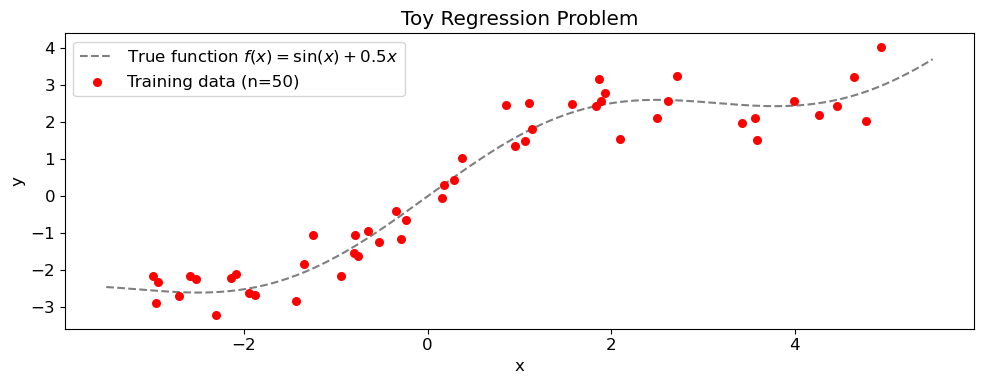

In [4]:
# True function (unknown to the model)
def f_true(x):
    return np.sin(x) + 0.8 * x

noise_std = 0.5

# Large population (for bootstrap / multiple learning samples)
N_pop = 500
X_pop = np.random.uniform(-3, 5, N_pop)
y_pop = f_true(X_pop) + np.random.randn(N_pop) * noise_std

# Default training set: 30 points
n_train = 50
X_train = X_pop[:n_train]
y_train = y_pop[:n_train]

# Test grid
X_test = np.linspace(-3.5, 5.5, 300)

# Visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5, label='True function $f(x) = \\sin(x) + 0.5x$')
ax.scatter(X_train, y_train, c='red', s=30, zorder=5, label=f'Training data (n={n_train})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Toy Regression Problem')
ax.legend(); plt.tight_layout(); plt.show()

---
## 2. Bias-Variance Visualization

### 2.1 Multiple Learning Samples

The key idea: if we had access to **many different training sets** drawn from the same distribution,
each trained model would be slightly different. The **spread** of these models is the variance,
and how far their **average** is from the truth is the bias.

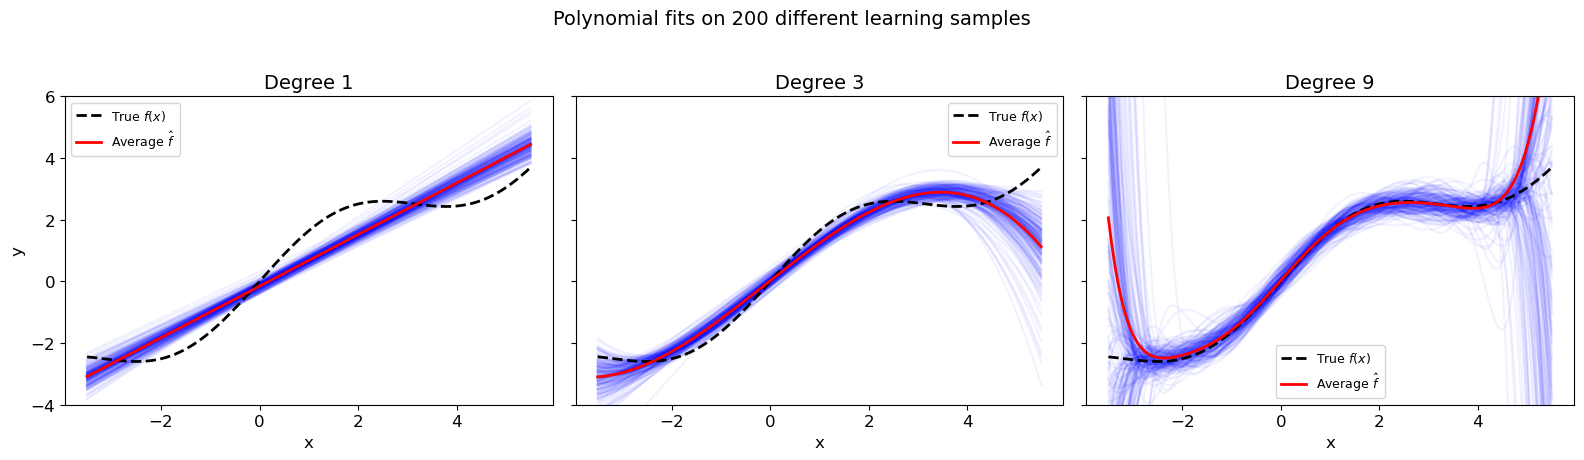

Degree 1: High bias (average far from truth), low variance (lines are tight)
Degree 3: Moderate bias and variance — the sweet spot
Degree 9: Low bias (average near truth), HIGH variance (lines are wild)


In [5]:
# Generate multiple learning samples and fit polynomials of different degrees
n_samples = 200  # number of different learning samples
n_per_sample = 40  # points per learning sample
degrees = [1, 3, 9]

# Standardize x for numerical stability with high-degree polynomials
x_mu, x_sig = X_pop.mean(), X_pop.std()
X_test_s = (X_test - x_mu) / x_sig

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

all_predictions = {}  # degree -> (n_samples, len(X_test))

for ax, deg in zip(axes, degrees):
    preds = np.zeros((n_samples, len(X_test)))
    
    for i in range(n_samples):
        # Draw a new learning sample
        idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
        X_s, y_s = X_pop[idx], y_pop[idx]
        X_s_std = (X_s - x_mu) / x_sig
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', Warning)
            coeffs = np.polyfit(X_s_std, y_s, deg)
        preds[i] = np.polyval(coeffs, X_test_s)
        ax.plot(X_test, preds[i], alpha=0.05, color='blue')
    
    all_predictions[deg] = preds
    mean_pred = preds.mean(axis=0)
    
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=2, label='True $f(x)$')
    ax.plot(X_test, mean_pred, 'r-', linewidth=2, label='Average $\\hat{f}$')
    ax.set_title(f'Degree {deg}', fontsize=14)
    ax.set_ylim(-4, 6); ax.set_xlabel('x')
    ax.legend(fontsize=9)

axes[0].set_ylabel('y')
fig.suptitle(f'Polynomial fits on {n_samples} different learning samples', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print('Degree 1: High bias (average far from truth), low variance (lines are tight)')
print('Degree 3: Moderate bias and variance — the sweet spot')
print('Degree 9: Low bias (average near truth), HIGH variance (lines are wild)')

### 2.2 Computing Bias², Variance, and Total Error Numerically

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4134749/3346382575.py:32: SyntaxWarning: invalid escape sequence '\s'
  ax1.axhline(y=noise_std**2, color='gray', linestyle=':', label=f'Noise $\sigma^2 = {noise_std**2}$')
/tmp/ipykernel_4134749/3346382575.py:42: SyntaxWarning: invalid escape sequence '\s'
  ax2.axhline(y=noise_std**2, color='gray', linestyle=':', label=f'Noise $\sigma^2$')


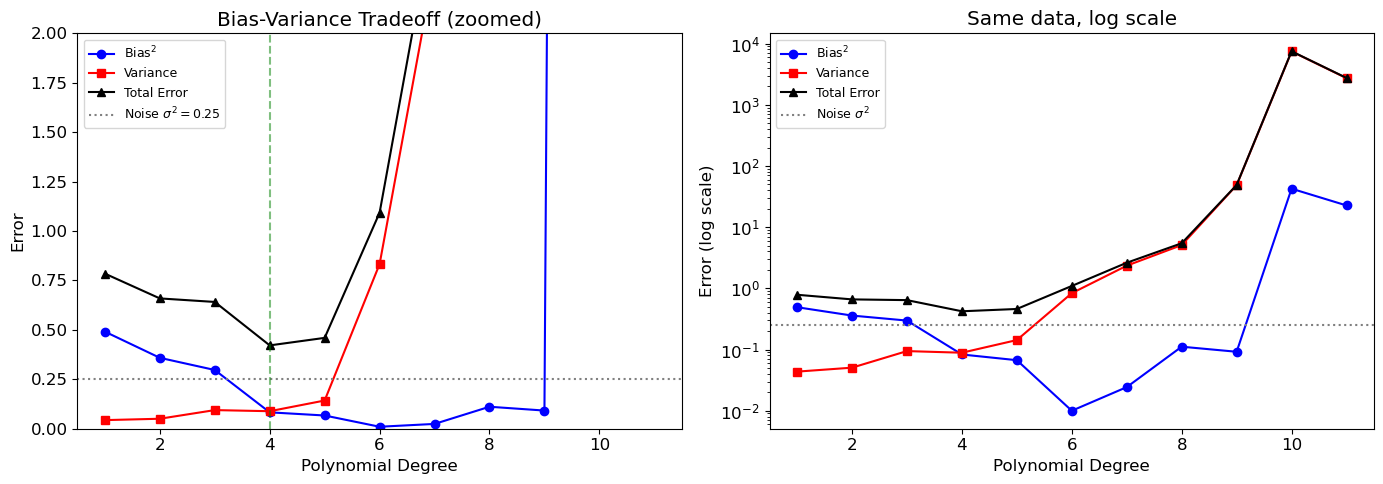

Optimal polynomial degree: 4
  Bias^2 = 0.0829
  Variance = 0.0886
  Noise = 0.2500
  Total = 0.4215

Note: Variance explodes for high degrees — this IS the bias-variance tradeoff!
High-degree polynomials are numerically unstable and wildly overfit.


In [6]:
# Compute bias, variance, and total error for different polynomial degrees
test_degrees = range(1, 12)
bias2_list, var_list, total_list = [], [], []

for deg in test_degrees:
    preds = np.zeros((n_samples, len(X_test)))
    for i in range(n_samples):
        idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
        X_s, y_s = X_pop[idx], y_pop[idx]
        X_s_std = (X_s - x_mu) / x_sig
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', Warning)
            coeffs = np.polyfit(X_s_std, y_s, deg)
        preds[i] = np.polyval(coeffs, X_test_s)
    
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((f_true(X_test) - mean_pred) ** 2)
    variance = np.mean(preds.var(axis=0))
    total = bias2 + variance + noise_std ** 2
    
    bias2_list.append(bias2)
    var_list.append(variance)
    total_list.append(total)

# The U-shaped curve — use two views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale, zoomed to low degrees where the U is clear
ax1.plot(list(test_degrees), bias2_list, 'b-o', label='Bias$^2$', markersize=6)
ax1.plot(list(test_degrees), var_list, 'r-s', label='Variance', markersize=6)
ax1.plot(list(test_degrees), total_list, 'k-^', label='Total Error', markersize=6)
ax1.axhline(y=noise_std**2, color='gray', linestyle=':', label=f'Noise $\sigma^2 = {noise_std**2}$')
ax1.set_xlabel('Polynomial Degree'); ax1.set_ylabel('Error')
ax1.set_title('Bias-Variance Tradeoff (zoomed)')
ax1.set_ylim(0, 2.0); ax1.legend(fontsize=9)
ax1.axvline(x=list(test_degrees)[np.argmin(total_list)], color='green', linestyle='--', alpha=0.5, label='Optimal')

# Right: log scale shows full picture
ax2.plot(list(test_degrees), bias2_list, 'b-o', label='Bias$^2$', markersize=6)
ax2.plot(list(test_degrees), var_list, 'r-s', label='Variance', markersize=6)
ax2.plot(list(test_degrees), total_list, 'k-^', label='Total Error', markersize=6)
ax2.axhline(y=noise_std**2, color='gray', linestyle=':', label=f'Noise $\sigma^2$')
ax2.set_xlabel('Polynomial Degree'); ax2.set_ylabel('Error (log scale)')
ax2.set_title('Same data, log scale')
ax2.set_yscale('log'); ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

best_deg = list(test_degrees)[np.argmin(total_list)]
print(f'Optimal polynomial degree: {best_deg}')
print(f'  Bias^2 = {bias2_list[best_deg-1]:.4f}')
print(f'  Variance = {var_list[best_deg-1]:.4f}')
print(f'  Noise = {noise_std**2:.4f}')
print(f'  Total = {total_list[best_deg-1]:.4f}')
print(f'\nNote: Variance explodes for high degrees — this IS the bias-variance tradeoff!')
print(f'High-degree polynomials are numerically unstable and wildly overfit.')

---
## 3. KNN Bias-Variance

For K-Nearest Neighbors, the error decomposition has a clean form:

$$E[(Y-\hat{f}(x))^2] = \underbrace{\left(f(x) - \frac{1}{k}\sum_{i=1}^{k}f(N_i(x))\right)^2}_{\text{Bias}^2} + \underbrace{\frac{\sigma^2}{k}}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Noise}}$$

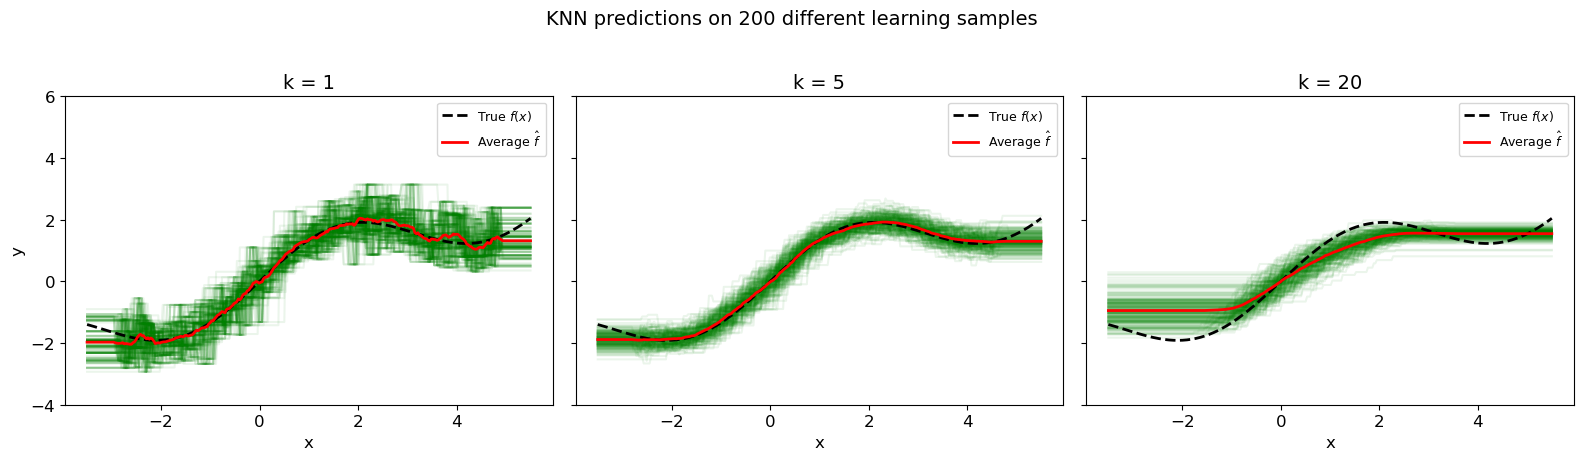

k=1:  Low bias (follows truth closely), HIGH variance (very noisy)
k=5:  Moderate bias and variance — good balance
k=20: High bias (oversmoothed), low variance (stable)


In [5]:
def knn_predict(X_train, y_train, X_test, k=5):
    """K-Nearest Neighbors regression: average the k closest training points."""
    predictions = np.zeros(len(X_test))
    for i, x in enumerate(X_test):
        distances = np.abs(X_train - x)
        nn_idx = np.argsort(distances)[:k]
        predictions[i] = y_train[nn_idx].mean()
    return predictions

# Show KNN predictions for different k on multiple learning samples
k_values = [1, 5, 20]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, k in zip(axes, k_values):
    preds = np.zeros((n_samples, len(X_test)))
    for i in range(n_samples):
        idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
        X_s, y_s = X_pop[idx], y_pop[idx]
        preds[i] = knn_predict(X_s, y_s, X_test, k=k)
        ax.plot(X_test, preds[i], alpha=0.08, color='green')
    
    mean_pred = preds.mean(axis=0)
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=2, label='True $f(x)$')
    ax.plot(X_test, mean_pred, 'r-', linewidth=2, label='Average $\\hat{f}$')
    ax.set_title(f'k = {k}', fontsize=14)
    ax.set_ylim(-4, 6); ax.set_xlabel('x')
    ax.legend(fontsize=9)

axes[0].set_ylabel('y')
fig.suptitle(f'KNN predictions on {n_samples} different learning samples', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print('k=1:  Low bias (follows truth closely), HIGH variance (very noisy)')
print('k=5:  Moderate bias and variance — good balance')
print('k=20: High bias (oversmoothed), low variance (stable)')

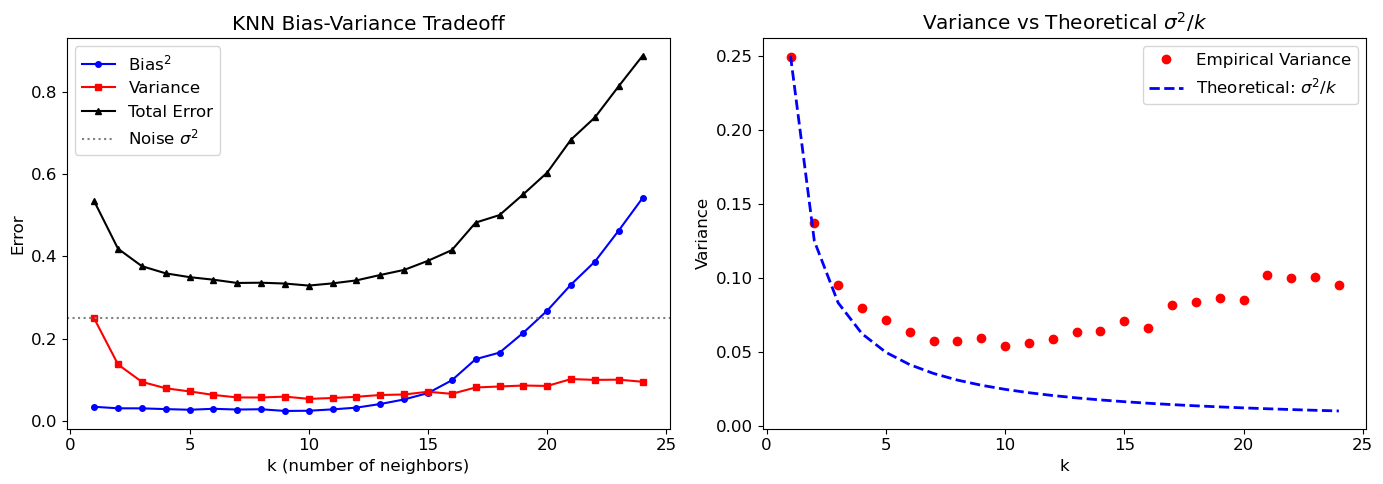

Optimal k = 10
Note: empirical variance follows sigma^2/k — the theory works!


In [6]:
# Compute bias^2 and variance as function of k
k_range = range(1, 25)
knn_bias2, knn_var, knn_total = [], [], []

for k in k_range:
    preds = np.zeros((n_samples, len(X_test)))
    for i in range(n_samples):
        idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
        X_s, y_s = X_pop[idx], y_pop[idx]
        preds[i] = knn_predict(X_s, y_s, X_test, k=k)
    
    mean_pred = preds.mean(axis=0)
    b2 = np.mean((f_true(X_test) - mean_pred) ** 2)
    v = np.mean(preds.var(axis=0))
    knn_bias2.append(b2)
    knn_var.append(v)
    knn_total.append(b2 + v + noise_std**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bias-variance tradeoff
axes[0].plot(list(k_range), knn_bias2, 'b-o', markersize=4, label='Bias$^2$')
axes[0].plot(list(k_range), knn_var, 'r-s', markersize=4, label='Variance')
axes[0].plot(list(k_range), knn_total, 'k-^', markersize=4, label='Total Error')
axes[0].axhline(y=noise_std**2, color='gray', linestyle=':', label='Noise $\\sigma^2$')
axes[0].set_xlabel('k (number of neighbors)')
axes[0].set_ylabel('Error')
axes[0].set_title('KNN Bias-Variance Tradeoff')
axes[0].legend()

# Right: verify variance ~ sigma^2 / k
theoretical_var = [noise_std**2 / k for k in k_range]
axes[1].plot(list(k_range), knn_var, 'ro', markersize=6, label='Empirical Variance')
axes[1].plot(list(k_range), theoretical_var, 'b--', linewidth=2, label='Theoretical: $\\sigma^2 / k$')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Variance')
axes[1].set_title('Variance vs Theoretical $\\sigma^2/k$')
axes[1].legend()

plt.tight_layout(); plt.show()

best_k = list(k_range)[np.argmin(knn_total)]
print(f'Optimal k = {best_k}')
print(f'Note: empirical variance follows sigma^2/k — the theory works!')

---
## 4. Regularization Demo

Regularization adds a penalty to prevent weights from becoming too large.
This **slightly increases bias** but **significantly reduces variance**.

- **L2 (Ridge):** $\min_w ||y - Xw||^2 + \lambda ||w||^2$ — shrinks all weights
- **L1 (Lasso):** $\min_w ||y - Xw||^2 + \lambda ||w||_1$ — drives some weights to zero (sparsity)

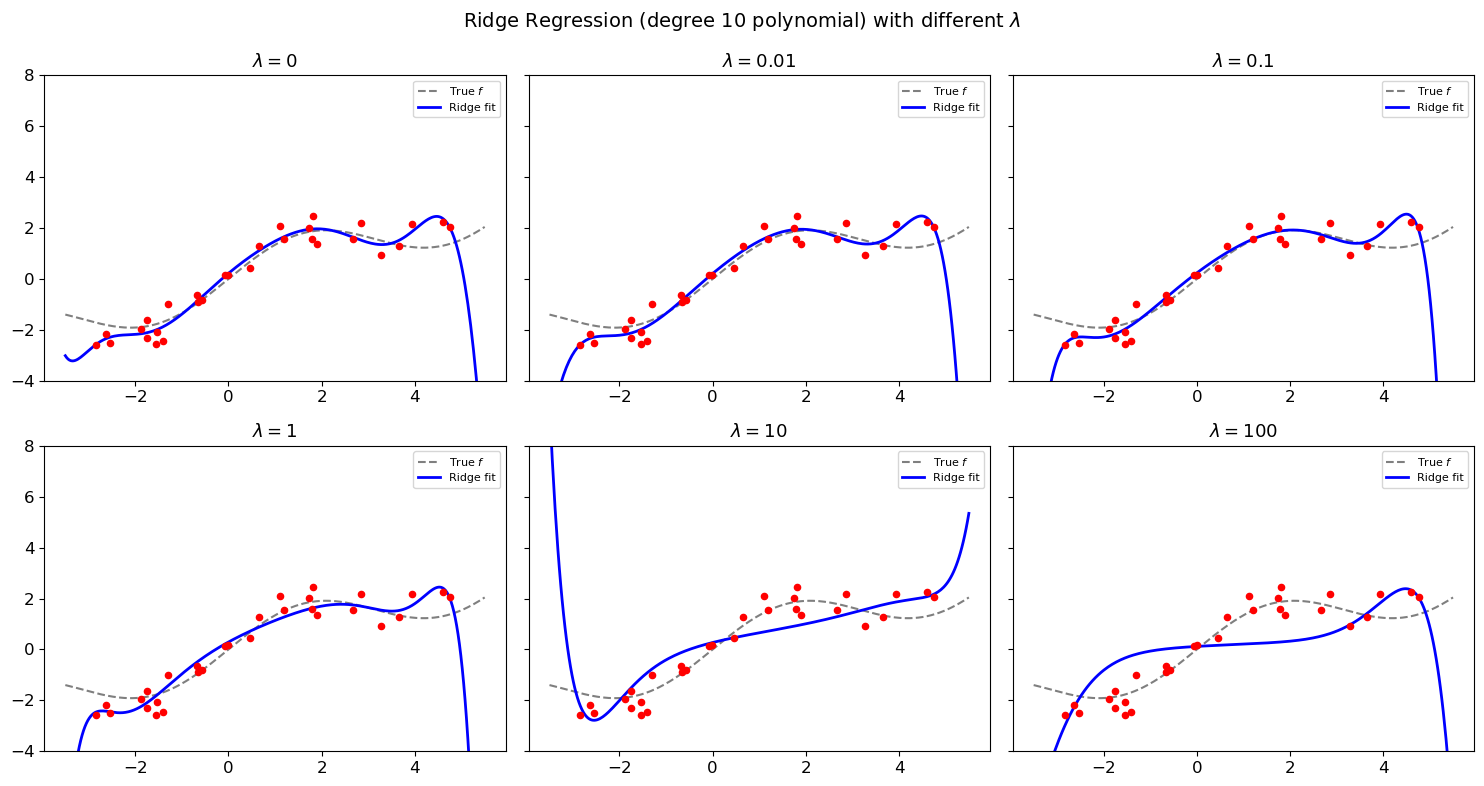

lambda=0:   No regularization → overfits (high variance)
lambda=0.1: Slight regularization → good fit
lambda=100: Heavy regularization → underfits (high bias)


In [7]:
# Build polynomial feature matrix
degree = 10

def poly_features(x, deg):
    """Create polynomial feature matrix [1, x, x^2, ..., x^deg]."""
    return np.column_stack([x**i for i in range(deg + 1)])

# Standardize features for better conditioning
x_mean, x_std = X_train.mean(), X_train.std()
X_train_s = (X_train - x_mean) / x_std
X_test_s = (X_test - x_mean) / x_std

Phi_train = poly_features(X_train_s, degree)
Phi_test = poly_features(X_test_s, degree)

# Ridge regression (closed-form): w = (X^T X + lambda I)^{-1} X^T y
def ridge_fit(Phi, y, lam):
    n_features = Phi.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # don't regularize bias term
    return np.linalg.solve(Phi.T @ Phi + lam * I, Phi.T @ y)

# Show effect of different lambda values
lambdas = [0, 0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, lam in zip(axes.flat, lambdas):
    w = ridge_fit(Phi_train, y_train, lam)
    y_pred = Phi_test @ w
    
    ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5, label='True $f$')
    ax.plot(X_test, y_pred, 'b-', linewidth=2, label='Ridge fit')
    ax.scatter(X_train, y_train, c='red', s=20, zorder=5)
    ax.set_title(f'$\\lambda = {lam}$', fontsize=13)
    ax.set_ylim(-4, 8)
    ax.legend(fontsize=8)

fig.suptitle(f'Ridge Regression (degree {degree} polynomial) with different $\\lambda$', fontsize=14)
plt.tight_layout(); plt.show()

print('lambda=0:   No regularization → overfits (high variance)')
print('lambda=0.1: Slight regularization → good fit')
print('lambda=100: Heavy regularization → underfits (high bias)')

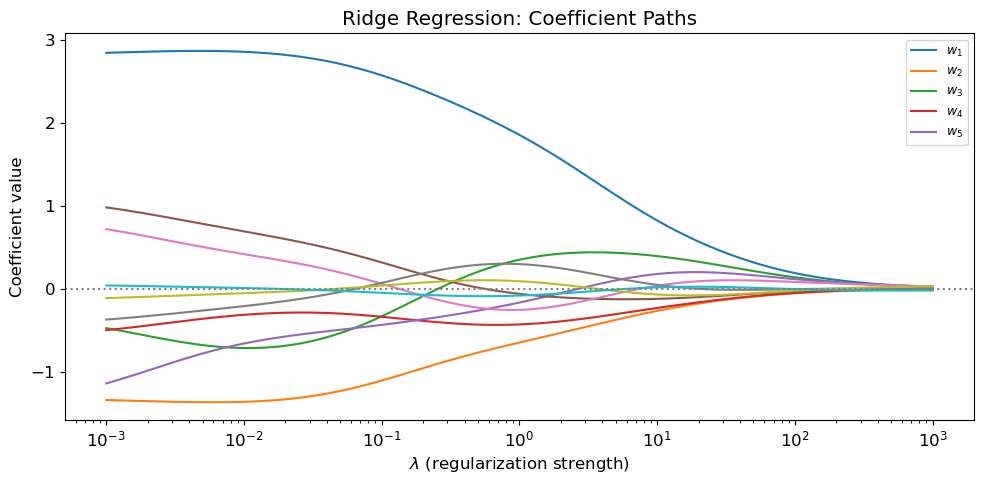

All coefficients shrink toward zero as lambda increases.
But NONE reach exactly zero — that's the key difference from L1 (Lasso).


In [8]:
# Coefficient paths: how weights change as lambda increases
lambda_range = np.logspace(-3, 3, 100)
coeff_paths = np.zeros((len(lambda_range), degree + 1))

for i, lam in enumerate(lambda_range):
    coeff_paths[i] = ridge_fit(Phi_train, y_train, lam)

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(1, degree + 1):  # skip bias
    ax.plot(lambda_range, coeff_paths[:, j], label=f'$w_{j}$' if j <= 5 else None)

ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (regularization strength)')
ax.set_ylabel('Coefficient value')
ax.set_title('Ridge Regression: Coefficient Paths')
ax.axhline(y=0, color='gray', linestyle=':')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('All coefficients shrink toward zero as lambda increases.')
print('But NONE reach exactly zero — that\'s the key difference from L1 (Lasso).')

In [9]:
if HAS_SKLEARN:
    # L1 (Lasso) vs L2 (Ridge) comparison using sklearn
    from sklearn.preprocessing import PolynomialFeatures, StandardScaler
    from sklearn.pipeline import make_pipeline
    
    lam = 0.01
    
    ridge_model = make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=lam)
    )
    lasso_model = make_pipeline(
        PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=lam, max_iter=10000)
    )
    
    ridge_model.fit(X_train.reshape(-1, 1), y_train)
    lasso_model.fit(X_train.reshape(-1, 1), y_train)
    
    y_ridge = ridge_model.predict(X_test.reshape(-1, 1))
    y_lasso = lasso_model.predict(X_test.reshape(-1, 1))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, y_pred, name, color in [
        (axes[0], y_ridge, 'Ridge (L2)', 'blue'),
        (axes[1], y_lasso, 'Lasso (L1)', 'orange')
    ]:
        ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5, label='True $f$')
        ax.plot(X_test, y_pred, color=color, linewidth=2, label=name)
        ax.scatter(X_train, y_train, c='red', s=20, zorder=5)
        ax.set_ylim(-4, 8); ax.set_xlabel('x'); ax.legend()
        ax.set_title(f'{name} ($\\lambda = {lam}$)')
    
    plt.tight_layout(); plt.show()
    
    # Show sparsity
    ridge_coefs = ridge_model[-1].coef_
    lasso_coefs = lasso_model[-1].coef_
    
    print(f'Ridge: {np.sum(np.abs(ridge_coefs) < 1e-4)} of {len(ridge_coefs)} coefficients near zero')
    print(f'Lasso: {np.sum(np.abs(lasso_coefs) < 1e-4)} of {len(lasso_coefs)} coefficients near zero')
    print('\nLasso induces SPARSITY — automatic feature selection!')
else:
    print('sklearn not available. The Ridge demo above shows the key ideas.')
    print('L1 (Lasso) differs by driving some weights to EXACTLY zero → feature selection.')

sklearn not available. The Ridge demo above shows the key ideas.
L1 (Lasso) differs by driving some weights to EXACTLY zero → feature selection.


---
## 5. Bagging Demo

> **Bootstrap Aggregating**: Train $M$ models on bootstrap samples, average their predictions.

Bagging reduces **variance** without increasing bias:
$$\text{Var}[\bar{f}] = \rho \cdot \text{Var}[\hat{f}] + \frac{1-\rho}{M} \cdot \text{Var}[\hat{f}]$$
where $\rho$ is the average correlation between models.

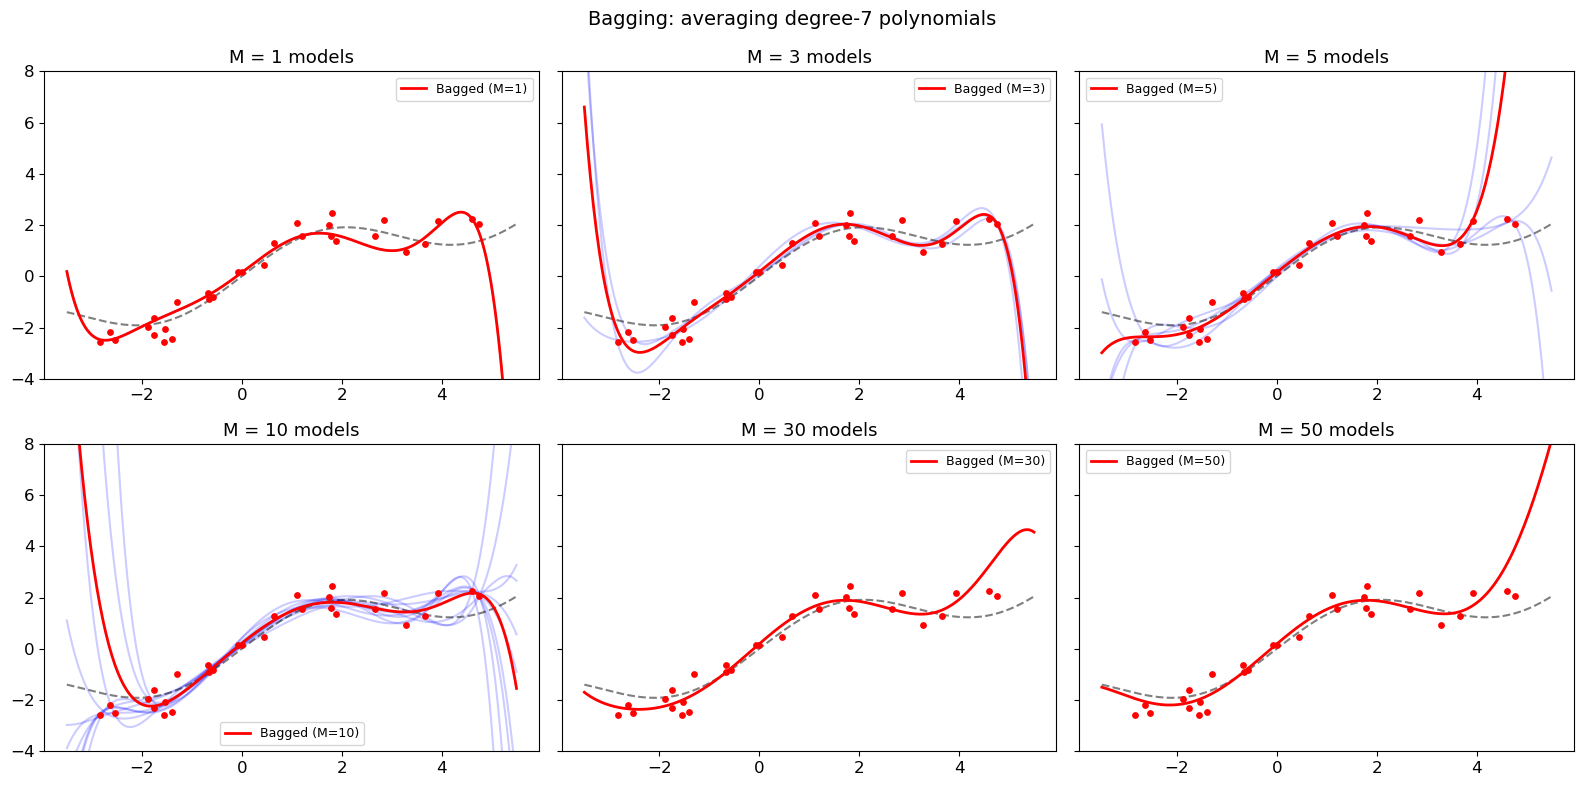

As M increases, the ensemble prediction becomes smoother and more stable.
Individual models may overfit, but their average does not!


In [10]:
# Bagging from scratch with polynomial base learners
base_degree = 7  # high degree = high variance
M_values = [1, 3, 5, 10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)

for ax, M in zip(axes.flat, M_values):
    ensemble_preds = np.zeros((M, len(X_test)))
    
    for m in range(M):
        # Bootstrap sample
        idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_b, y_b = X_train[idx], y_train[idx]
        X_b_s = (X_b - x_mean) / x_std
        Phi_b = poly_features(X_b_s, base_degree)
        
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', Warning)
            w = ridge_fit(Phi_b, y_b, 0.001)  # tiny regularization for stability
        Phi_t = poly_features(X_test_s, base_degree)
        ensemble_preds[m] = Phi_t @ w
        
        if M <= 10:
            ax.plot(X_test, ensemble_preds[m], alpha=0.2, color='blue')
    
    bagged_pred = ensemble_preds.mean(axis=0)
    ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5)
    ax.plot(X_test, bagged_pred, 'r-', linewidth=2, label=f'Bagged (M={M})')
    ax.scatter(X_train, y_train, c='red', s=15, zorder=5)
    ax.set_title(f'M = {M} models', fontsize=13)
    ax.set_ylim(-4, 8)
    ax.legend(fontsize=9)

fig.suptitle(f'Bagging: averaging degree-{base_degree} polynomials', fontsize=14)
plt.tight_layout(); plt.show()

print('As M increases, the ensemble prediction becomes smoother and more stable.')
print('Individual models may overfit, but their average does not!')

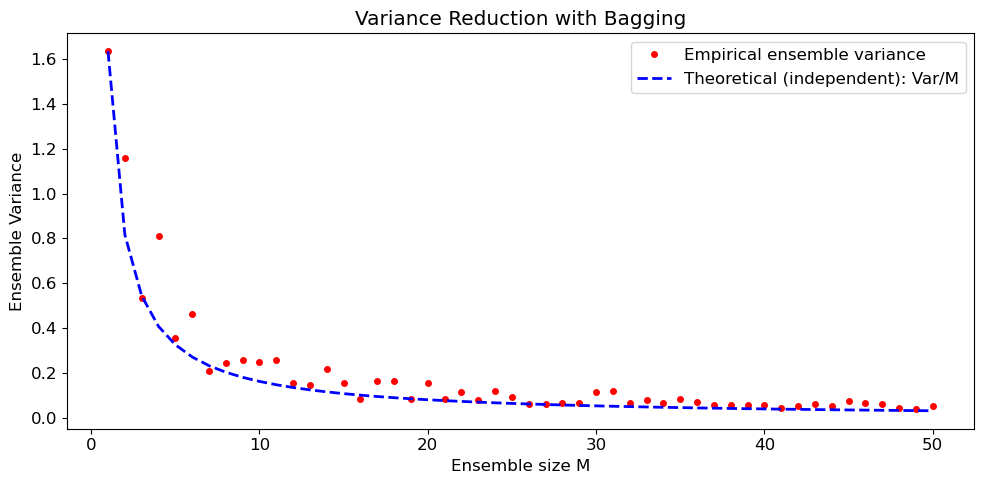

Single model variance: 1.6332
Ensemble (M=50) variance: 0.0540
Reduction factor: 30.3x

Note: variance does NOT reach zero — models are correlated (rho > 0)!
This floor is rho * Var[f_hat] — the irreducible correlation.


In [11]:
# Variance reduction as function of ensemble size M
M_range = range(1, 51)
ensemble_variances = []

n_repeats = 30  # repeat the whole bagging process

for M in M_range:
    repeat_preds = np.zeros((n_repeats, len(X_test)))
    for r in range(n_repeats):
        # One full bagging run
        bag_preds = np.zeros((M, len(X_test)))
        for m in range(M):
            idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
            X_s, y_s = X_pop[idx], y_pop[idx]
            X_s_scaled = (X_s - x_mean) / x_std
            Phi_s = poly_features(X_s_scaled, base_degree)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', Warning)
                w = ridge_fit(Phi_s, y_s, 0.001)
            Phi_t = poly_features(X_test_s, base_degree)
            bag_preds[m] = Phi_t @ w
        repeat_preds[r] = bag_preds.mean(axis=0)
    
    ensemble_variances.append(np.mean(repeat_preds.var(axis=0)))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(M_range), ensemble_variances, 'ro', markersize=4, label='Empirical ensemble variance')

# Theoretical: Var/M (if independent) and rho*Var + (1-rho)/M*Var
var_single = ensemble_variances[0]  # M=1
theoretical_independent = [var_single / M for M in M_range]
ax.plot(list(M_range), theoretical_independent, 'b--', linewidth=2,
        label=f'Theoretical (independent): Var/{"M"}')

ax.set_xlabel('Ensemble size M')
ax.set_ylabel('Ensemble Variance')
ax.set_title('Variance Reduction with Bagging')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Single model variance: {var_single:.4f}')
print(f'Ensemble (M=50) variance: {ensemble_variances[-1]:.4f}')
print(f'Reduction factor: {var_single / ensemble_variances[-1]:.1f}x')
print(f'\nNote: variance does NOT reach zero — models are correlated (rho > 0)!')
print('This floor is rho * Var[f_hat] — the irreducible correlation.')

---
## 6. Boosting Demo

> **Boosting**: Sequentially fit models to **residuals** of previous models.
> Each new model corrects the errors of the ensemble so far.

Boosting reduces **bias** (primarily), unlike bagging which reduces variance.

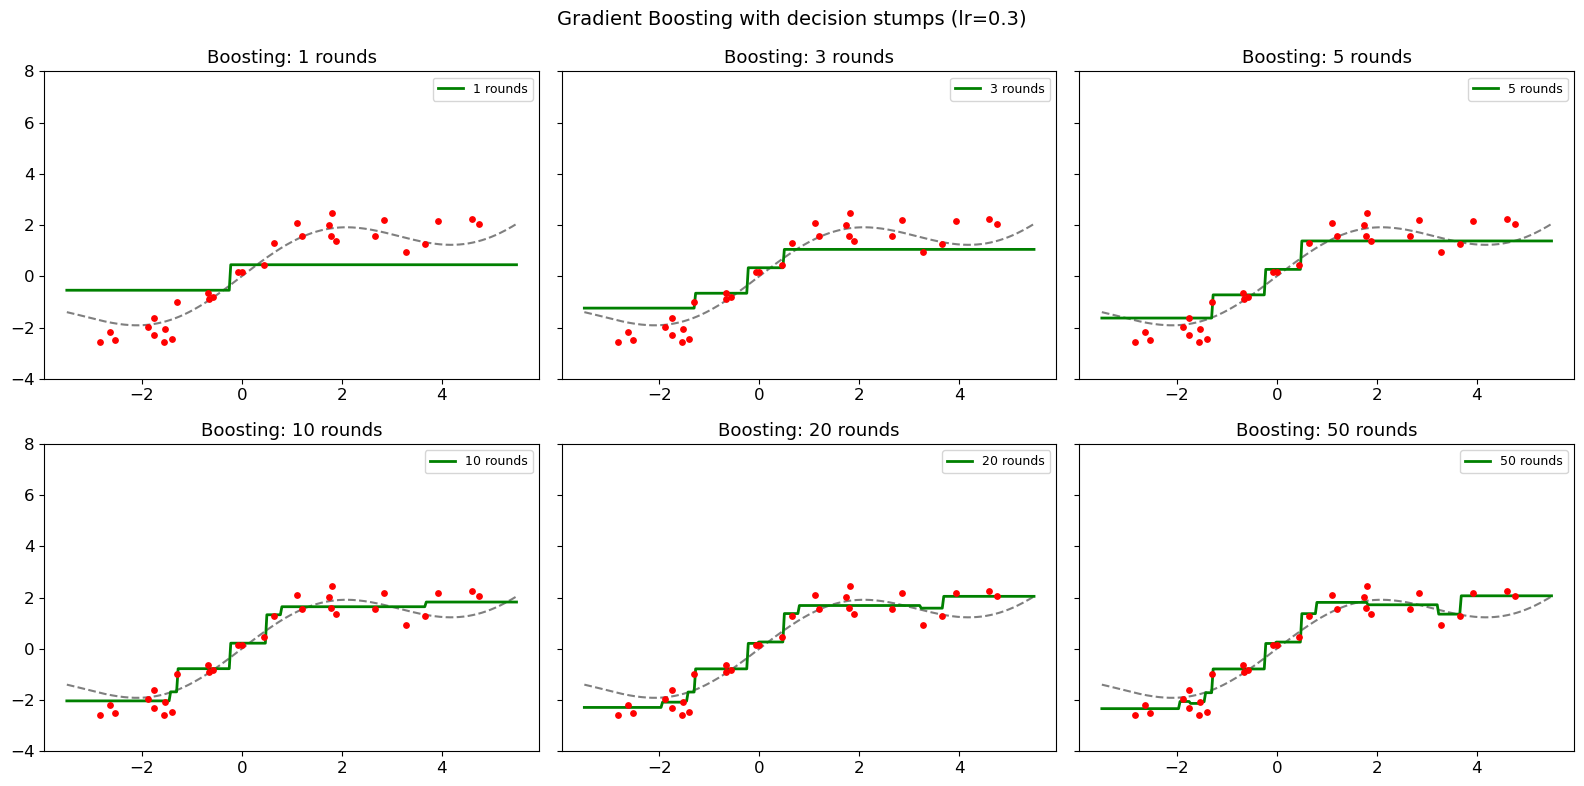

Round 1:  Very high bias — just a single step function
Round 10: Bias decreasing — starting to capture the shape
Round 50: Low bias — closely follows the data

Boosting progressively REDUCES BIAS by fitting residuals!


In [12]:
# Simple gradient boosting from scratch
def simple_tree_stump(X, y):
    """Fit a depth-1 decision stump: find best split on single feature."""
    best_mse = np.inf
    best_pred = np.mean(y) * np.ones_like(y)
    best_split = None
    
    thresholds = np.percentile(X, np.linspace(10, 90, 20))
    for t in thresholds:
        left = X <= t
        right = ~left
        if left.sum() < 2 or right.sum() < 2:
            continue
        pred = np.where(left, y[left].mean(), y[right].mean())
        mse = np.mean((y - pred) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_split = t
            best_left_val = y[left].mean()
            best_right_val = y[right].mean()
    
    return best_split, best_left_val, best_right_val

def stump_predict(X, split, left_val, right_val):
    return np.where(X <= split, left_val, right_val)

# Gradient boosting
learning_rate = 0.3
n_rounds = [1, 3, 5, 10, 20, 50]
max_rounds = max(n_rounds)

# Train all rounds
stumps = []
residuals = y_train.copy()
current_pred_train = np.zeros(len(X_train))

for t in range(max_rounds):
    split, lv, rv = simple_tree_stump(X_train, residuals)
    stumps.append((split, lv, rv))
    update = learning_rate * stump_predict(X_train, split, lv, rv)
    current_pred_train += update
    residuals = y_train - current_pred_train

# Plot predictions at different boosting rounds
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)

for ax, nr in zip(axes.flat, n_rounds):
    # Predict on test set using first nr stumps
    y_pred = np.zeros(len(X_test))
    for t in range(nr):
        split, lv, rv = stumps[t]
        y_pred += learning_rate * stump_predict(X_test, split, lv, rv)
    
    ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5)
    ax.plot(X_test, y_pred, 'g-', linewidth=2, label=f'{nr} rounds')
    ax.scatter(X_train, y_train, c='red', s=15, zorder=5)
    ax.set_title(f'Boosting: {nr} rounds', fontsize=13)
    ax.set_ylim(-4, 8); ax.legend(fontsize=9)

fig.suptitle(f'Gradient Boosting with decision stumps (lr={learning_rate})', fontsize=14)
plt.tight_layout(); plt.show()

print('Round 1:  Very high bias — just a single step function')
print('Round 10: Bias decreasing — starting to capture the shape')
print('Round 50: Low bias — closely follows the data')
print('\nBoosting progressively REDUCES BIAS by fitting residuals!')

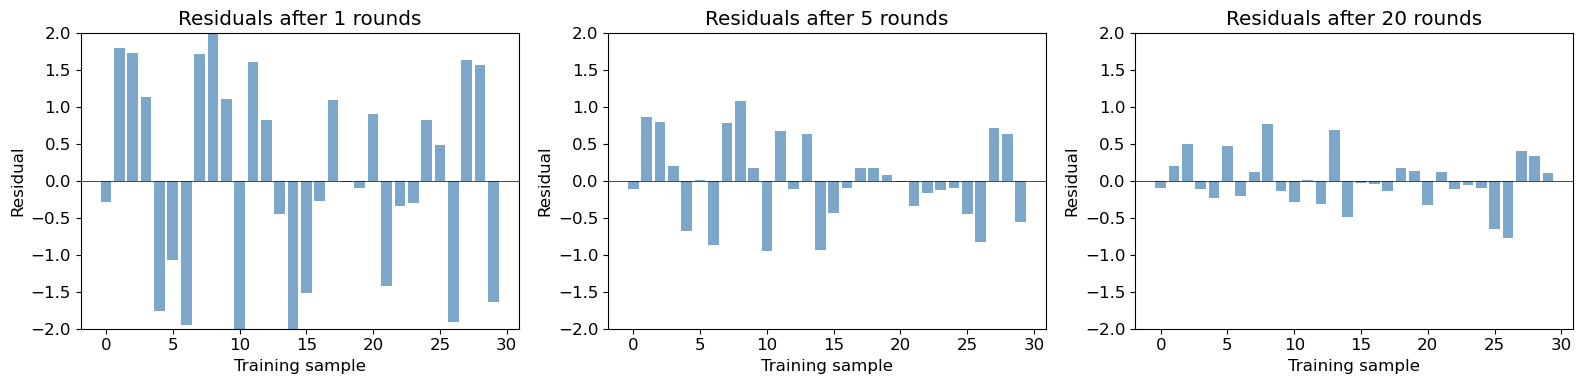

Each boosting round reduces the residuals that the next round must fit.


In [13]:
# Show residuals shrinking over boosting rounds
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rounds_to_show = [1, 5, 20]

for ax, nr in zip(axes, rounds_to_show):
    # Compute training residuals after nr rounds
    pred_train = np.zeros(len(X_train))
    for t in range(nr):
        split, lv, rv = stumps[t]
        pred_train += learning_rate * stump_predict(X_train, split, lv, rv)
    resid = y_train - pred_train
    
    ax.bar(range(len(resid)), resid, color='steelblue', alpha=0.7)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_title(f'Residuals after {nr} rounds')
    ax.set_xlabel('Training sample'); ax.set_ylabel('Residual')
    ax.set_ylim(-2, 2)

plt.tight_layout(); plt.show()
print('Each boosting round reduces the residuals that the next round must fit.')

### Exercise: Ensemble Prediction by Hand

Given 5 models with predictions [2.1, 2.5, 1.8, 2.3, 2.0] for a test point:

In [14]:
# Exercise from the slides
preds = np.array([2.1, 2.5, 1.8, 2.3, 2.0])

print('Predictions:', preds)
print(f'\nBagging (simple average): {preds.mean():.2f}')
print(f'Variance: {preds.var():.4f}')
print(f'Std dev: {preds.std():.4f}')
print(f'95% CI: [{preds.mean() - 1.96*preds.std():.3f}, {preds.mean() + 1.96*preds.std():.3f}]')

# Weighted (boosting-like): more weight to models with lower training error
weights = np.array([0.3, 0.15, 0.25, 0.1, 0.2])  # example weights
weighted_pred = np.average(preds, weights=weights)
print(f'\nBoosting (weighted): {weighted_pred:.3f}  (weights = {weights})')

Predictions: [2.1 2.5 1.8 2.3 2. ]

Bagging (simple average): 2.14
Variance: 0.0584
Std dev: 0.2417
95% CI: [1.666, 2.614]

Boosting (weighted): 2.085  (weights = [0.3  0.15 0.25 0.1  0.2 ])


---
## 7. Random Forests (if sklearn available)

> Random Forest = Bagging + Random feature subset at each split
>
> This further **decorrelates** the trees, lowering $\rho$ and thus reducing ensemble variance even more.

In [15]:
if HAS_SKLEARN:
    # We need 2D features for sklearn, so create polynomial features
    from sklearn.preprocessing import PolynomialFeatures
    
    poly = PolynomialFeatures(degree=3)
    X_train_2d = poly.fit_transform(X_train.reshape(-1, 1))
    X_test_2d = poly.transform(X_test.reshape(-1, 1))
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # Single deep tree
    tree = DecisionTreeRegressor(max_depth=10)
    tree.fit(X_train.reshape(-1, 1), y_train)
    y_tree = tree.predict(X_test.reshape(-1, 1))
    axes[0].plot(X_test, y_tree, 'g-', linewidth=2)
    axes[0].set_title('Single Deep Tree (depth=10)')
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train.reshape(-1, 1), y_train)
    y_rf = rf.predict(X_test.reshape(-1, 1))
    axes[1].plot(X_test, y_rf, 'b-', linewidth=2)
    axes[1].set_title('Random Forest (100 trees)')
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    gb.fit(X_train.reshape(-1, 1), y_train)
    y_gb = gb.predict(X_test.reshape(-1, 1))
    axes[2].plot(X_test, y_gb, 'm-', linewidth=2)
    axes[2].set_title('Gradient Boosting (100 rounds)')
    
    for ax in axes:
        ax.plot(X_test, f_true(X_test), 'k--', alpha=0.5, label='True $f$')
        ax.scatter(X_train, y_train, c='red', s=20, zorder=5)
        ax.set_ylim(-4, 8); ax.set_xlabel('x')
        ax.legend(fontsize=9)
    
    plt.tight_layout(); plt.show()
    
    # Training errors
    for name, y_pred_tr in [
        ('Single Tree', tree.predict(X_train.reshape(-1, 1))),
        ('Random Forest', rf.predict(X_train.reshape(-1, 1))),
        ('Grad. Boosting', gb.predict(X_train.reshape(-1, 1)))
    ]:
        mse = np.mean((y_train - y_pred_tr)**2)
        print(f'{name:16s} Train MSE: {mse:.4f}')
    
    print('\nSingle tree: overfits (staircase-like), high variance')
    print('Random Forest: smooth prediction, reduced variance')
    print('Gradient Boosting: also smooth, reduced bias')
else:
    print('sklearn not available. The bagging/boosting demos above show the key concepts.')
    print('Random Forest = Bagging of decision trees + random feature subsets at each split.')

sklearn not available. The bagging/boosting demos above show the key concepts.
Random Forest = Bagging of decision trees + random feature subsets at each split.


---
## 8. Bagging vs Boosting: Side-by-Side Comparison

Let's see both methods on the same data to understand their different strategies.

Bagging     Bias^2 = 0.0751  Variance = 0.1931  Total = 0.5182
Boosting    Bias^2 = 0.0323  Variance = 0.0580  Total = 0.3403


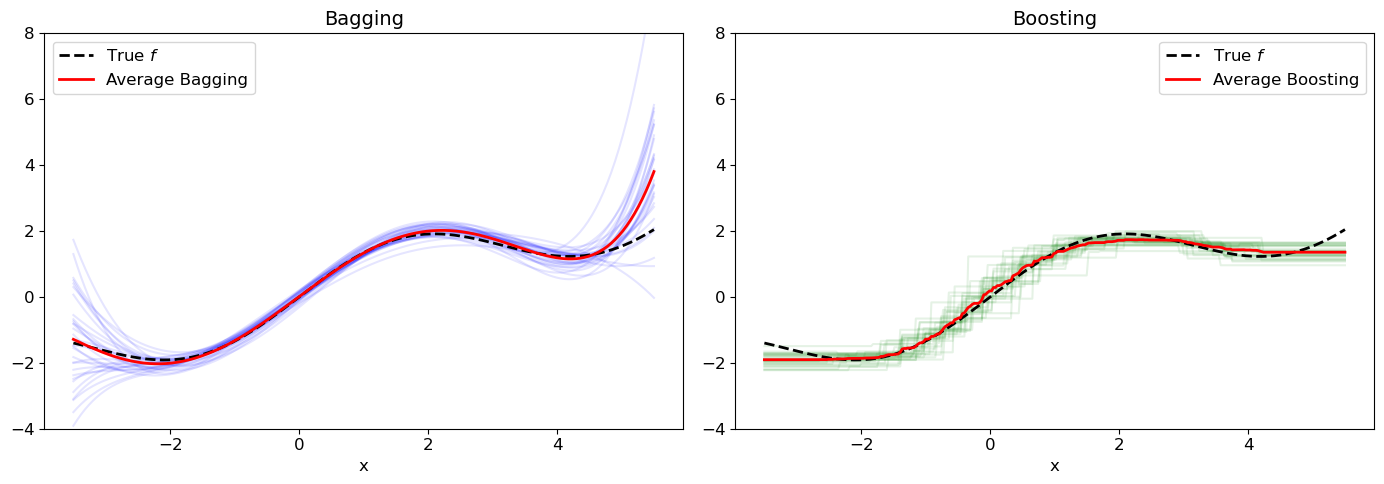


Bagging: individual lines spread out (variance) but average is near truth (low bias)
Boosting: individual lines are tighter (lower variance) but may have systematic offset (bias from weak learners)


In [16]:
# Bagging vs Boosting: bias and variance comparison
n_experiment = 30
M_ensemble = 20

bagging_preds = np.zeros((n_experiment, len(X_test)))
boosting_preds = np.zeros((n_experiment, len(X_test)))

for exp in range(n_experiment):
    # Draw new learning sample
    idx = np.random.choice(N_pop, size=n_per_sample, replace=True)
    X_s, y_s = X_pop[idx], y_pop[idx]
    X_s_scaled = (X_s - x_mean) / x_std
    
    # Bagging: M polynomial models on bootstrap subsamples
    bag_preds_inner = np.zeros((M_ensemble, len(X_test)))
    for m in range(M_ensemble):
        b_idx = np.random.choice(len(X_s), size=len(X_s), replace=True)
        X_b_s = X_s_scaled[b_idx]
        y_b = y_s[b_idx]
        Phi_b = poly_features(X_b_s, 5)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', Warning)
            w = ridge_fit(Phi_b, y_b, 0.01)
        Phi_t = poly_features(X_test_s, 5)
        bag_preds_inner[m] = Phi_t @ w
    bagging_preds[exp] = bag_preds_inner.mean(axis=0)
    
    # Boosting: sequential stump fitting
    boost_pred_test = np.zeros(len(X_test))
    boost_pred_train = np.zeros(len(X_s))
    resid = y_s.copy()
    for t in range(M_ensemble):
        split, lv, rv = simple_tree_stump(X_s, resid)
        boost_pred_train += 0.3 * stump_predict(X_s, split, lv, rv)
        boost_pred_test += 0.3 * stump_predict(X_test, split, lv, rv)
        resid = y_s - boost_pred_train
    boosting_preds[exp] = boost_pred_test

# Compute bias and variance
for name, preds in [('Bagging', bagging_preds), ('Boosting', boosting_preds)]:
    mean_p = preds.mean(axis=0)
    bias2 = np.mean((f_true(X_test) - mean_p)**2)
    var = np.mean(preds.var(axis=0))
    print(f'{name:10s}  Bias^2 = {bias2:.4f}  Variance = {var:.4f}  Total = {bias2+var+noise_std**2:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, preds, color in [
    (axes[0], 'Bagging', bagging_preds, 'blue'),
    (axes[1], 'Boosting', boosting_preds, 'green')
]:
    for i in range(n_experiment):
        ax.plot(X_test, preds[i], alpha=0.1, color=color)
    mean_p = preds.mean(axis=0)
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=2, label='True $f$')
    ax.plot(X_test, mean_p, 'r-', linewidth=2, label=f'Average {name}')
    ax.set_title(name, fontsize=14)
    ax.set_ylim(-4, 8); ax.set_xlabel('x'); ax.legend()

plt.tight_layout(); plt.show()

print('\nBagging: individual lines spread out (variance) but average is near truth (low bias)')
print('Boosting: individual lines are tighter (lower variance) but may have systematic offset (bias from weak learners)')

---
## 9. Summary

In [17]:
print('\u250c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u252c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2510')
print('\u2502 Method             \u2502 Reduces         \u2502 Risk            \u2502 Key Idea        \u2502')
print('\u251c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u253c\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2524')
print('\u2502 Ridge (L2)          \u2502 Variance        \u2502 Underfitting    \u2502 Shrink weights  \u2502')
print('\u2502 Lasso (L1)          \u2502 Variance        \u2502 Underfitting    \u2502 Sparse weights  \u2502')
print('\u2502 Bagging             \u2502 Variance        \u2502 None (safe!)    \u2502 Average models  \u2502')
print('\u2502 Random Forest       \u2502 Variance++      \u2502 None (safe!)    \u2502 + Random splits \u2502')
print('\u2502 AdaBoost            \u2502 Bias            \u2502 Overfitting     \u2502 Focus on errors \u2502')
print('\u2502 Gradient Boosting   \u2502 Bias            \u2502 Overfitting     \u2502 Fit residuals   \u2502')
print('\u2514\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2534\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2518')
print()
print('Decision guide:')
print('  \u2022 High variance (overfitting)?  \u2192 Regularization or Bagging')
print('  \u2022 High bias (underfitting)?     \u2192 Boosting')
print('  \u2022 Tabular data, quick baseline? \u2192 Random Forest')
print('  \u2022 Tabular data, max accuracy?   \u2192 Gradient Boosting (XGBoost/LightGBM)')
print('  \u2022 Many irrelevant features?     \u2192 Lasso (L1) for feature selection')
print('  \u2022 Correlated features?           \u2192 Ridge (L2) or Elastic Net')

┌────────────────────┬───────────────┬───────────────┬────────────────┐
│ Method             │ Reduces         │ Risk            │ Key Idea        │
├────────────────────┼───────────────┼───────────────┼────────────────┤
│ Ridge (L2)          │ Variance        │ Underfitting    │ Shrink weights  │
│ Lasso (L1)          │ Variance        │ Underfitting    │ Sparse weights  │
│ Bagging             │ Variance        │ None (safe!)    │ Average models  │
│ Random Forest       │ Variance++      │ None (safe!)    │ + Random splits │
│ AdaBoost            │ Bias            │ Overfitting     │ Focus on errors │
│ Gradient Boosting   │ Bias            │ Overfitting     │ Fit residuals   │
└────────────────────┴───────────────┴───────────────┴────────────────┘

Decision guide:
  • High variance (overfitting)?  → Regularization or Bagging
  • High bias (underfitting)?     → Boosting
  • Tabular data, quick baseline? → Random Forest
  • Tabular data, max accuracy?   → Gradient Boosting (XGBoost/Li